## Building a Simple Stock Trading Strategy

In [1]:
# Import the libraries
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

In [4]:
# Download the data
sp500_ticker = '^GSPC'

spy = yf.download(sp500_ticker, start='2010-01-04', end='2026-03-18')
spy

/tmp/ipykernel_9336/3704226050.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download(sp500_ticker, start='2010-01-04', end='2026-03-18')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2010-01-04,1132.989990,1133.869995,1116.560059,1116.560059,3991400000
2010-01-05,1136.520020,1136.630005,1129.660034,1132.660034,2491020000
2010-01-06,1137.140015,1139.189941,1133.949951,1135.709961,4972660000
2010-01-07,1141.689941,1142.459961,1131.319946,1136.270020,5270680000
2010-01-08,1144.979980,1145.390015,1136.219971,1140.520020,4389590000
...,...,...,...,...,...
2026-03-11,6775.799805,6811.149902,6745.589844,6790.089844,5511090000
2026-03-12,6672.620117,6740.879883,6670.399902,6740.879883,6292170000


In [7]:
# Drop a level in multi index column
spy = spy.droplevel(level=1, axis=1)

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,1132.989990,1133.869995,1116.560059,1116.560059,3991400000
2010-01-05,1136.520020,1136.630005,1129.660034,1132.660034,2491020000
2010-01-06,1137.140015,1139.189941,1133.949951,1135.709961,4972660000
2010-01-07,1141.689941,1142.459961,1131.319946,1136.270020,5270680000
2010-01-08,1144.979980,1145.390015,1136.219971,1140.520020,4389590000
...,...,...,...,...,...
2026-03-11,6775.799805,6811.149902,6745.589844,6790.089844,5511090000
2026-03-12,6672.620117,6740.879883,6670.399902,6740.879883,6292170000
2026-03-13,6632.189941,6733.299805,6623.919922,6673.490234,5337120000


In [8]:
# Use only the Close price column
data = pd.DataFrame()
data['Close'] = spy['Close']

In [9]:
data

,Close
Date,
2010-01-04,1132.989990
2010-01-05,1136.520020
2010-01-06,1137.140015
2010-01-07,1141.689941
2010-01-08,1144.979980
...,...
2026-03-11,6775.799805
2026-03-12,6672.620117
2026-03-13,6632.189941


In [10]:
# Compute the moving average
data['MA'] = data['Close'].rolling(50).mean()
data

,Close,MA
Date,,
2010-01-04,1132.989990,NaN
2010-01-05,1136.520020,NaN
2010-01-06,1137.140015,NaN
2010-01-07,1141.689941,NaN
2010-01-08,1144.979980,NaN
...,...,...
2026-03-11,6775.799805,6894.079785
2026-03-12,6672.620117,6889.417383
2026-03-13,6632.189941,6884.136377


In [11]:
# Create the simple trading strategy
'''
If the S&P500 close price is above the 50-day moving average then we buy indicated by the number 1.
If the S&P500 close price is below the 50-day moving average then we sell indicated by the number 0
'''
data['signal'] = np.where(data['Close'] > data['MA'], 1, 0)

# We want to enter a position on the next day and not the same day that the signal was generated.
data['position'] = data['signal'].shift(1)

In [12]:
# Compute the returns
data['SPY_Return'] = data['Close'].pct_change() # Get the daily returns
data['Strat_Return'] = data['SPY_Return'] * data['position'] # Get the strategy returns

# Get the cumulative returns 
data['BH_Equity'] = (1 + data['SPY_Return']).cumprod() # Get the cumulative returns for the S&P500 (Shows what a $1 investment grows into)
data['Strat_Equity'] = (1 + data['Strat_Return']).cumprod() # Get the cumulative returns for the strategy 

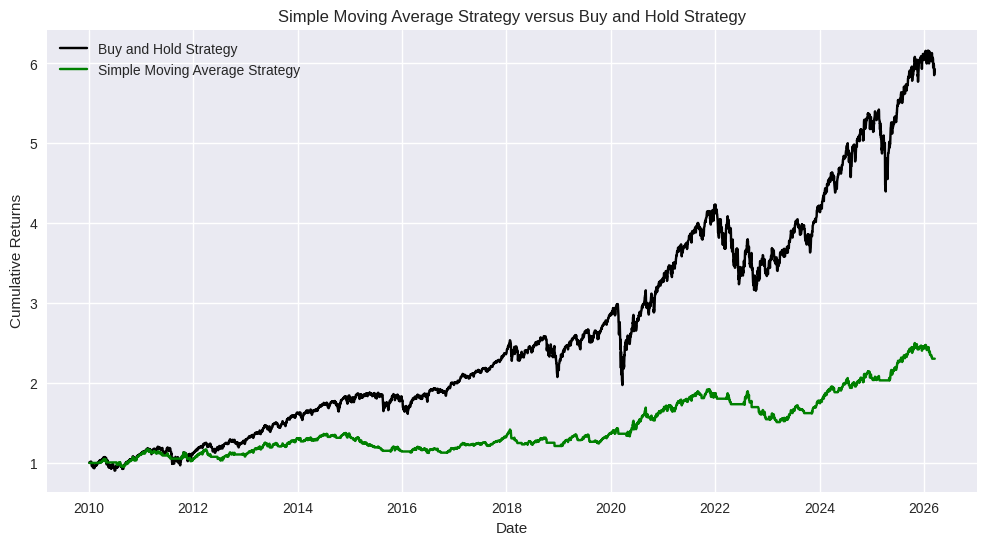

In [14]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['BH_Equity'], label='Buy and Hold Strategy', color='black')
plt.plot(data.index, data['Strat_Equity'], label='Simple Moving Average Strategy', color='green')
plt.title('Simple Moving Average Strategy versus Buy and Hold Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Print the final values
bh_final = data['BH_Equity'].iloc[-1]
strat_final = data['Strat_Equity'].iloc[-1]

print('== Simple Strategy Summary == ')
print(f'Buy and Hold Strategy Final Cumulative Returns: {bh_final:.4f}')
print(f'Simple Moving Average Strategy Final Cumulative Returns: {strat_final:.4f}')

== Simple Strategy Summary == 
Buy and Hold Strategy Final Cumulative Returns: 5.9278
Simple Moving Average Strategy Final Cumulative Returns: 2.3047
